In [1]:
import psi4
import pandas as pd
import os
import numpy as np
import pickle
from lps_rscf import lps_solver
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
def prim_gauss(a, d, r):
    g = ( 2 * a / np.pi ) ** ( 3 / 4 ) * np.exp( - a * r ** 2 )
    return d * g

lps_a_list = [
    11387194.5850786, 5815282.94190191, 2969784.65079439, 1516627.98873367,
    774520.959152738, 395537.152566831, 201995.358823884, 103156.238855453,
    52680.4659115021, 26903.1860742975, 13739.0854166734, 7016.36109438299,
    3583.15866840945, 1829.86962476550, 934.489134729210, 477.230689612032,
    243.715119463182, 124.461944187287, 63.5609952513411, 32.4597220758638,
    16.5767315800501, 8.46550778330153, 4.32321786011102, 2.20780762884063,
    1.12749685157938, 0.575797063890464, 0.294051604951678, 0.150168091845475,
    7.668876968794860e-002, 3.916389509898707e-002, 2.000046011385546e-002
]
UGBS_Be_a_list = [
    201995.358823884, 103156.238855453,
    52680.4659115021, 26903.1860742975, 13739.0854166734, 7016.36109438299,
    3583.15866840945, 1829.86962476550, 934.489134729210, 477.230689612032,
    243.715119463182, 124.461944187287, 63.5609952513411, 32.4597220758638,
    16.5767315800501, 8.46550778330153, 4.32321786011102, 2.20780762884063,
    1.12749685157938, 0.575797063890464, 0.294051604951678, 0.150168091845475,
    7.668876968794860e-002, 3.916389509898707e-002, 2.000046011385546e-002
]

def rad_distrib(D, a_list, r):
    res = 0
    for i in range(0, len(a_list)):
        for j in range(0, len(a_list)):
            res += D[i,j] * prim_gauss(a_list[i], 1, r) * prim_gauss(a_list[j], 1, r)
    return res

In [3]:
psi4.core.set_output_file('output.dat', False)

mol = psi4.geometry("""
units bohr
0 1
Be
symmetry c1
""")

rhf_e_ugbs, rhf_wfn_ugbs = psi4.energy('HF/UGBS', return_wfn=True)
D_rhf_ugbs = rhf_wfn_ugbs.Da().np + rhf_wfn_ugbs.Db().np

rhf_e_31s, rhf_wfn_31s = psi4.energy('HF/UGBS_S', return_wfn=True)
D_rhf_31s = rhf_wfn_31s.Da().np + rhf_wfn_31s.Db().np

In [4]:
# np.set_printoptions(suppress=True, precision=2, floatmode='fixed')
# print(r)

r = np.arange(0.0, 10.01, 0.01)
rhf_ugbs_density = rad_distrib(D_rhf_ugbs, UGBS_Be_a_list, r)
rhf_31s_density = rad_distrib(D_rhf_31s, lps_a_list, r)

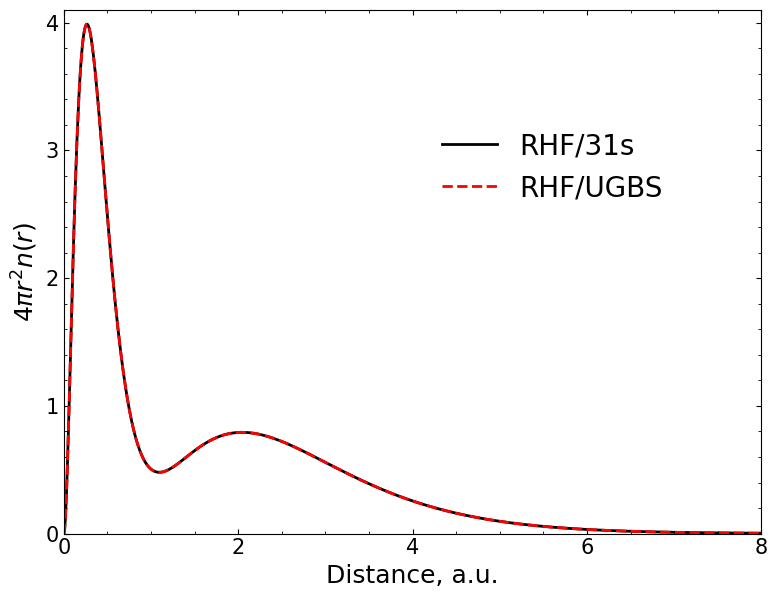

In [12]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot(r, 4 * np.pi * r **2 * rhf_31s_density, label='RHF/31s', color='black', linestyle='-', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * rhf_ugbs_density, label='RHF/UGBS', color='red', linestyle='--', linewidth=2)
ax.legend(loc='center', bbox_to_anchor=(0.70, 0.70), fontsize=20, frameon=False)
ax.tick_params(axis='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
ax.set_xlabel("Distance, a.u.", fontsize=18)
ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
ax.axis([0.0, 8, 0, 4.1])
ax.set_xticks(np.arange(0.0, 10.0, 2.0))
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(np.arange(0.0, 4.1, 1.0))
ax.tick_params(axis='y', labelsize=15)

In [13]:
METHOD = "W FA"
TP = ['LDA_K_TF', 0.0]
LAMBDA = 1.0
EXC = ['GGA_X_PBE', 0.0, 'LDA_C_VWN', 0.0]
FA = [True, 1.0]
DIIS = True
MAX_ITER = 1000
DAMPING = [0.1, 0.0, 0.001]
D_guess = None
verbose=False

psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

E, D_wfa, mu, iterations = lps_solver(MAX_ITER,TP,EXC,LAMBDA,mol,DAMPING,FA,D_guess,DIIS,verbose)
wfa_31s_density = rad_distrib(D_wfa.np, lps_a_list, r)

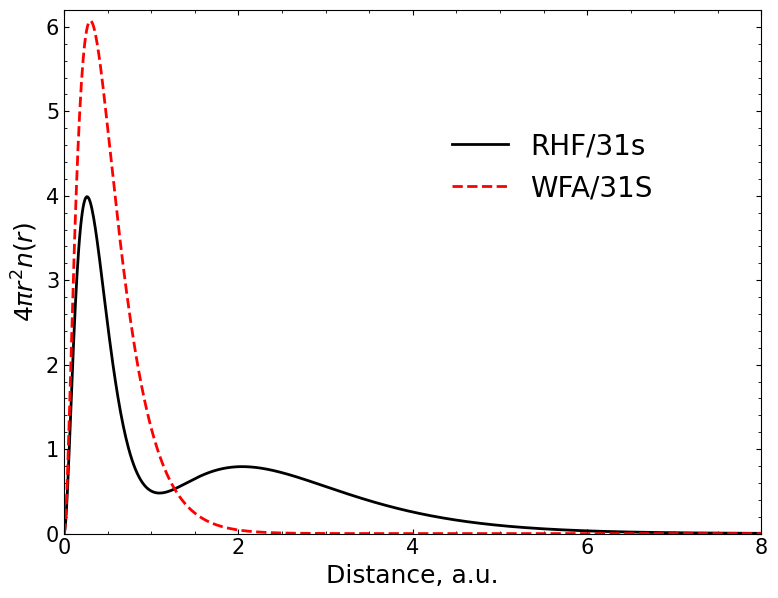

In [18]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot(r, 4 * np.pi * r **2 * rhf_31s_density, label='RHF/31s', color='black', linestyle='-', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * wfa_31s_density, label='WFA/31S', color='red', linestyle='--', linewidth=2)
ax.legend(loc='center', bbox_to_anchor=(0.70, 0.70), fontsize=20, frameon=False)
ax.tick_params(axis='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
ax.set_xlabel("Distance, a.u.", fontsize=18)
ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
ax.axis([0.0, 8, 0, 6.2])
ax.set_xticks(np.arange(0.0, 10.0, 2.0))
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(np.arange(0.0, 6.2, 1.0))
ax.tick_params(axis='y', labelsize=15)

In [19]:
METHOD = "TF0.166666W FA"
TP = ['LDA_K_TF', 1.0]
LAMBDA = 0.166666
EXC = ['GGA_X_PBE', 0.0, 'LDA_C_VWN', 0.0]
FA = [True, 1.0]
DIIS = True
MAX_ITER = 3000
DAMPING = [0.9, 0.9, 0.001]
D_guess = None
verbose=False

psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

E, D_fa, mu, iterations = lps_solver(MAX_ITER,TP,EXC,LAMBDA,mol,DAMPING,FA,D_guess,DIIS,verbose)
fa_31s_density = rad_distrib(D_fa.np, lps_a_list, r)

In [21]:
METHOD = "TF0.166666W LDA"
TP = ['LDA_K_TF', 1.0]
EXC = ['LDA_X', 1.0, 'LDA_C_VWN', 0.0]
FA = [False, 1.0]
E, D_lda, mu, iterations = lps_solver(MAX_ITER,TP,EXC,LAMBDA,mol,DAMPING,FA,D_guess,DIIS,verbose)
lda_31s_density = rad_distrib(D_lda.np, lps_a_list, r)

In [23]:
METHOD = "TF0.166666W PBE"
TP = ['LDA_K_TF', 1.0]
EXC = ['GGA_X_PBE', 1.0, 'LDA_C_VWN', 0.0]
FA = [False, 1.0]
E, D_pbe, mu, iterations = lps_solver(MAX_ITER,TP,EXC,LAMBDA,mol,DAMPING,FA,D_guess,DIIS,verbose)
pbe_31s_density = rad_distrib(D_pbe.np, lps_a_list, r)

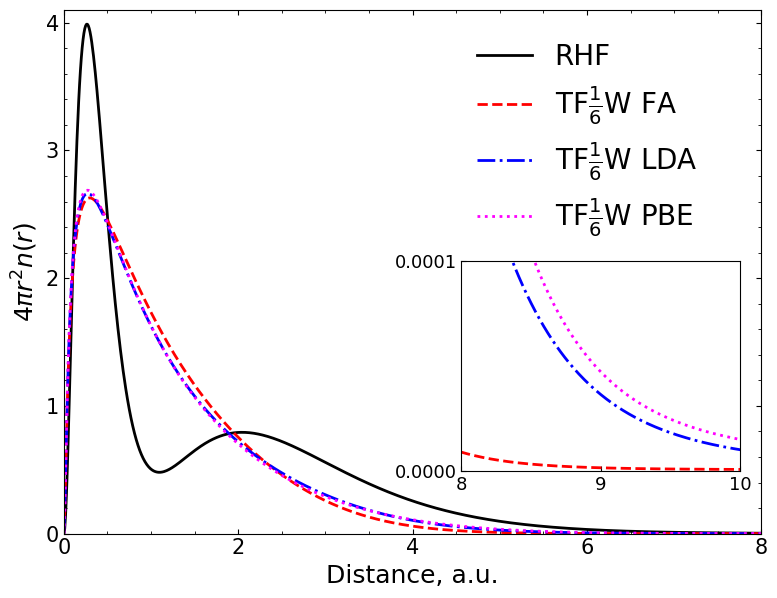

In [58]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot(r, 4 * np.pi * r **2 * rhf_31s_density, label='RHF', color='black', linestyle='-', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * fa_31s_density, label='TF$\\frac{1}{6}$W FA', color='red', linestyle='--', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * lda_31s_density, label='TF$\\frac{1}{6}$W LDA', color='blue', linestyle='-.', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * pbe_31s_density, label='TF$\\frac{1}{6}$W PBE', color='magenta', linestyle=':', linewidth=2)
ax.legend(loc='center', bbox_to_anchor=(0.75, 0.75), fontsize=20, frameon=False)
ax.tick_params(axis='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
ax.set_xlabel("Distance, a.u.", fontsize=18)
ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
ax.axis([0.0, 8, 0, 4.1])
ax.set_xticks(np.arange(0.0, 10.0, 2.0))
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(np.arange(0.0, 4.1, 1.0))
ax.tick_params(axis='y', labelsize=15)

axins = ax.inset_axes([0.57, 0.12, 0.4, 0.4])
axins.plot(r, 4 * np.pi * r **2 * fa_31s_density, color='red', linestyle='--', linewidth=2)
axins.plot(r, 4 * np.pi * r **2 * lda_31s_density, color='blue', linestyle='-.', linewidth=2)
axins.plot(r, 4 * np.pi * r **2 * pbe_31s_density, color='magenta', linestyle=':', linewidth=2)
axins.set_xlim(8, 10)
axins.set_ylim(0, 0.0001)
axins.set_xticks(np.arange(8.0, 11.0, 1.0))
axins.set_yticks(np.arange(0.0, 0.0002, 0.0001))
axins.tick_params(axis='both', labelsize=13, direction='in')

In [28]:
FILE_PATH = r'/Users/ivanbosko/Documents/UWO/Thesis/Manuscripts/FA_in_LPS/Calculations/twpbex_31s_scf_atom_densities.pkl'
if os.path.exists(FILE_PATH):
    with open(FILE_PATH, 'rb') as f:
        twpbe_dict = pickle.load(f)
Da = twpbe_dict['Be']['Da']
Db = twpbe_dict['Be']['Db']
D_twpbe = Da + Db
twpbe_31s_density = rad_distrib(D_twpbe, lps_a_list, r)

In [29]:
FILE_PATH = r'/Users/ivanbosko/Documents/UWO/Thesis/Manuscripts/FA_in_LPS/Calculations/twfax_31s_scf_atom_densities.pkl'
if os.path.exists(FILE_PATH):
    with open(FILE_PATH, 'rb') as f:
        twfa_dict = pickle.load(f)
Da = twfa_dict['Be']['Da']
Db = twfa_dict['Be']['Db']
D_twfa = Da + Db
twfa_31s_density = rad_distrib(D_twfa, lps_a_list, r)

In [30]:
FILE_PATH = r'/Users/ivanbosko/Documents/UWO/Thesis/Manuscripts/FA_in_LPS/Calculations/twldax_31s_scf_atom_densities.pkl'
if os.path.exists(FILE_PATH):
    with open(FILE_PATH, 'rb') as f:
        twlda_dict = pickle.load(f)
Da = twlda_dict['Be']['Da']
Db = twlda_dict['Be']['Db']
D_twlda = Da + Db
twlda_31s_density = rad_distrib(D_twlda, lps_a_list, r)

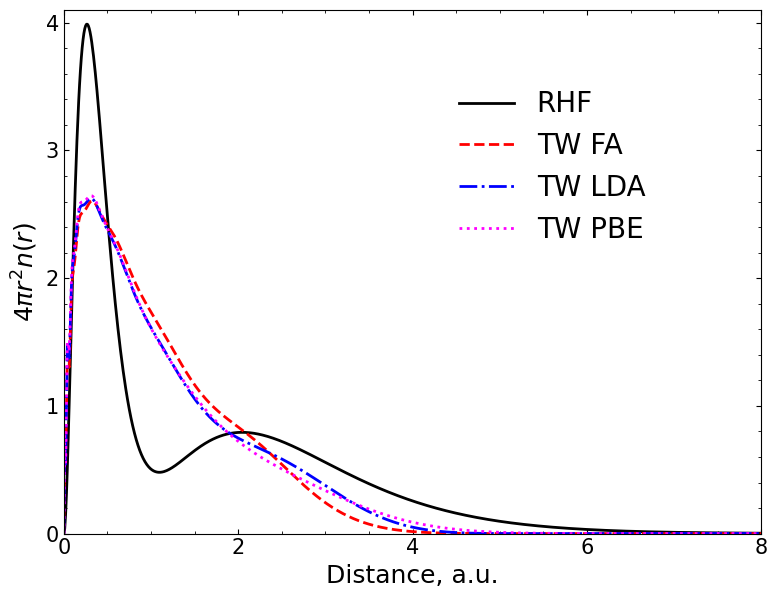

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot(r, 4 * np.pi * r **2 * rhf_31s_density, label='RHF', color='black', linestyle='-', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * twfa_31s_density, label='TW FA', color='red', linestyle='--', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * twlda_31s_density, label='TW LDA', color='blue', linestyle='-.', linewidth=2)
ax.plot(r, 4 * np.pi * r **2 * twpbe_31s_density, label='TW PBE', color='magenta', linestyle=':', linewidth=2)
ax.legend(loc='center', bbox_to_anchor=(0.70, 0.70), fontsize=20, frameon=False)
ax.tick_params(axis='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
ax.set_xlabel("Distance, a.u.", fontsize=18)
ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
ax.axis([0.0, 8, 0, 4.1])
ax.set_xticks(np.arange(0.0, 10.0, 2.0))
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(np.arange(0.0, 4.1, 1.0))
ax.tick_params(axis='y', labelsize=15)

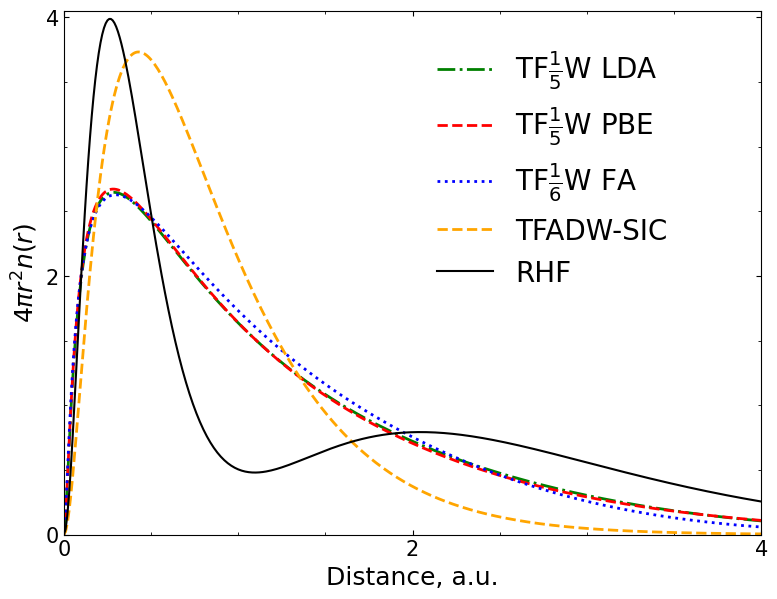

In [ ]:
# ax.plot(r, 4 * np.pi * r **2 * density_pbe, label='TF$\\frac{1}{5}$W PBE', color='red', linestyle='--', linewidth=2)
# ax.plot(r, 4 * np.pi * r **2 * density_fa, label='TF$\\frac{1}{6}$W FA', color='blue', linestyle=':', linewidth=2)
# ax.plot(r, 4 * np.pi * r **2 * density_sic, label='TFADW-SIC', color='orange', linestyle='--', linewidth=2)
# ax.plot(r, 4 * np.pi * r **2 * density_hf, label='RHF', color='black', linestyle='-', linewidth=1.5)

# ax.legend(loc='center', bbox_to_anchor=(0.70, 0.70), fontsize=20, frameon=False)
# ax.tick_params(axis='both', direction='in', top=True, right=True)
# ax.minorticks_on()
# ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
# ax.set_xlabel("Distance, a.u.", fontsize=18)
# ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
# ax.axis([0.0, 4, 0, 4.05])
# ax.set_xticks(np.arange(0.0, 6.0, 2.0))
# ax.tick_params(axis='x', labelsize=15)
# ax.set_yticks(np.arange(0.0, 5.0, 2.0))
# ax.tick_params(axis='y', labelsize=15)

# axins = ax.inset_axes([0.45, 0.45, 0.5, 0.5])
# axins.plot(r, 4 * np.pi * r **2 * density_lda, color='green', linestyle='-.', linewidth=2)
# axins.plot(r, 4 * np.pi * r **2 * density_pbe, color='red', linestyle='--', linewidth=2)
# axins.plot(r, 4 * np.pi * r **2 * density_fa, color='blue', linestyle=':', linewidth=2)
# axins.plot(r, 4 * np.pi * r **2 * density_hf, color='black', linestyle='-', linewidth=2)
# axins.set_xlim(6, 8)
# axins.set_ylim(0, 0.01)
# axins.set_xticks(np.arange(6.0, 9.0, 1.0))
# axins.set_yticks(np.arange(0.0, 0.02, 0.01))
# axins.tick_params(axis='both', labelsize=13, direction='in')

# plt.savefig(r'/Users/ivanbosko/Desktop/UWO/Thesis/Manuscripts/FA_in_LPS/LATEX/Figures/be_density_2.png', format='png')